In [3]:
# One-cell Jupyter pipeline:
# Heterogeneous 15-taxon primate mtDNA dataset
# NCBI FASTA download -> clean labels -> MAFFT alignment -> IQ-TREE ML reference tree
# Also saves T-label versions of ML trees for direct comparison with T-labeled distance matrices.

from pathlib import Path
import subprocess
import shutil
import sys
import importlib.util


# -----------------------------
# 0. Install Biopython into current Jupyter kernel if missing
# -----------------------------

if importlib.util.find_spec("Bio") is None:
    print("Biopython not found. Installing into current Jupyter kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "biopython"])

from Bio import Entrez, SeqIO, Phylo


# -----------------------------
# 1. User settings
# -----------------------------

# Replace with your real email. NCBI asks Entrez users to identify themselves.
NCBI_EMAIL = "your_email@example.com"

DATASET_TAG = "mtDNA15_heterogeneous_primate"

# Output folder
OUTDIR = Path(f"{DATASET_TAG}_ML_tree")
OUTDIR.mkdir(exist_ok=True)

# If MAFFT / IQ-TREE are not in PATH, write full paths here, for example:
# MAFFT_EXE = r"C:\path\to\mafft.bat"
# IQTREE_EXE = r"C:\path\to\iqtree2.exe"
MAFFT_EXE = None
IQTREE_EXE = None

# Re-run switches
FORCE_DOWNLOAD = False
FORCE_MAFFT = True
FORCE_IQTREE = True

# IQ-TREE prefix
PREFIX = OUTDIR / f"{DATASET_TAG}_IQTREE_ML"


# -----------------------------
# 1.1 Heterogeneous 15-taxon primate mtDNA accessions
# -----------------------------

TAXA = [
    # Hominoids
    {"accession": "NC_012920", "species": "Homo_sapiens",         "group": "Hominoidea"},
    {"accession": "NC_001643", "species": "Pan_troglodytes",      "group": "Hominoidea"},
    {"accession": "NC_001644", "species": "Pan_paniscus",         "group": "Hominoidea"},
    {"accession": "D38114",    "species": "Gorilla_gorilla",      "group": "Hominoidea"},
    {"accession": "NC_002083", "species": "Pongo_abelii",         "group": "Hominoidea"},
    {"accession": "NC_002082", "species": "Hylobates_lar",        "group": "Hominoidea"},

    # Old World monkeys
    {"accession": "NC_005943", "species": "Macaca_mulatta",       "group": "Old_World_monkeys"},
    {"accession": "NC_001992", "species": "Papio_hamadryas",      "group": "Old_World_monkeys"},
    {"accession": "NC_007009", "species": "Chlorocebus_aethiops", "group": "Old_World_monkeys"},
    {"accession": "NC_006901", "species": "Colobus_guereza",      "group": "Old_World_monkeys"},

    # New World monkeys
    {"accession": "NC_002763", "species": "Cebus_albifrons",      "group": "New_World_monkeys"},
    {"accession": "KM588314",  "species": "Callithrix_jacchus",   "group": "New_World_monkeys"},

    # More distant primate lineages
    {"accession": "NC_002811", "species": "Tarsius_bancanus",     "group": "Tarsiiformes"},
    {"accession": "NC_002765", "species": "Nycticebus_coucang",   "group": "Strepsirrhini"},
    {"accession": "NC_004025", "species": "Lemur_catta",          "group": "Strepsirrhini"},
]

ACCESSIONS = {row["accession"]: row["species"] for row in TAXA}

FULL_LABELS = [f"{row['species']}_{row['accession']}" for row in TAXA]
T_LABELS = [f"T{i + 1}" for i in range(len(TAXA))]

FULL_TO_T = dict(zip(FULL_LABELS, T_LABELS))
T_TO_FULL = dict(zip(T_LABELS, FULL_LABELS))


# -----------------------------
# 2. Helper functions
# -----------------------------

def find_executable(user_path, candidates):
    """
    Find executable either from user-specified path or from PATH.
    """
    if user_path:
        p = Path(user_path)
        if p.exists():
            return str(p)
        raise FileNotFoundError(f"Specified executable does not exist: {user_path}")

    for name in candidates:
        path = shutil.which(name)
        if path is not None:
            return path

    raise FileNotFoundError(
        f"Cannot find executable. Tried: {candidates}\n"
        f"Install it in your current system or set full path manually."
    )


def run_command(cmd, stdout_path=None, stderr_path=None):
    """
    Run external command and show useful error if it fails.
    """
    print("\nRunning command:")
    print(" ".join(map(str, cmd)))

    stdout_handle = open(stdout_path, "w", encoding="utf-8") if stdout_path else None
    stderr_handle = open(stderr_path, "w", encoding="utf-8") if stderr_path else None

    try:
        result = subprocess.run(
            list(map(str, cmd)),
            stdout=stdout_handle if stdout_handle else subprocess.PIPE,
            stderr=stderr_handle if stderr_handle else subprocess.PIPE,
            text=True,
            check=False,
        )

        if result.returncode != 0:
            if result.stderr:
                print("\nSTDERR:")
                print(result.stderr)
            raise RuntimeError(f"Command failed with exit code {result.returncode}")

        if result.stdout and not stdout_path:
            print(result.stdout[:1000])

    finally:
        if stdout_handle:
            stdout_handle.close()
        if stderr_handle:
            stderr_handle.close()


def accession_key(record_id: str) -> str:
    """
    Extract accession without version suffix.

    Handles:
        NC_012920.1
        D38114.1
        gi|251831106|ref|NC_012920.1|
    """
    rid = record_id.strip().split()[0]

    if "|" in rid:
        parts = [p for p in rid.split("|") if p]
        for p in parts:
            p0 = p.split(".")[0]
            if p0 in ACCESSIONS:
                return p0

    return rid.split(".")[0]


def download_fasta(accessions, output_fasta):
    """
    Download FASTA sequences from NCBI nucleotide database.
    """
    Entrez.email = NCBI_EMAIL
    ids = ",".join(accessions)

    print(f"Downloading {len(accessions)} sequences from NCBI...")
    with Entrez.efetch(
        db="nucleotide",
        id=ids,
        rettype="fasta",
        retmode="text",
    ) as handle:
        fasta_text = handle.read()

    if not fasta_text.strip():
        raise RuntimeError("NCBI returned empty FASTA text.")

    output_fasta.write_text(fasta_text, encoding="utf-8")
    print(f"Saved raw FASTA: {output_fasta}")


def sanitize_fasta(raw_fasta, clean_fasta, mapping_tsv, mapping_csv):
    """
    Replace NCBI FASTA headers with clean stable full labels.

    Important:
    RefSeq accessions contain underscores, e.g. NC_012920.
    Therefore, do not parse accession by splitting labels with '_'.
    """
    records = list(SeqIO.parse(raw_fasta, "fasta"))

    if len(records) == 0:
        raise ValueError("Downloaded FASTA contains no records.")

    found = set()
    clean_records_by_acc = {}
    mapping_rows = []

    for rec in records:
        acc = accession_key(rec.id)

        if acc not in ACCESSIONS:
            raise ValueError(
                f"Unexpected accession in FASTA: {rec.id}\n"
                f"Parsed accession key: {acc}\n"
                f"Original description: {rec.description}\n"
                f"Expected one of: {sorted(ACCESSIONS.keys())}"
            )

        taxon_row = next(row for row in TAXA if row["accession"] == acc)

        full_label = f"{taxon_row['species']}_{acc}"
        t_label = T_LABELS[[row["accession"] for row in TAXA].index(acc)]

        mapping_rows.append({
            "T_label": t_label,
            "full_label": full_label,
            "species": taxon_row["species"],
            "accession": acc,
            "group": taxon_row["group"],
            "original_id": rec.id,
            "original_description": rec.description,
            "sequence_length_raw": len(rec.seq),
        })

        rec.id = full_label
        rec.name = full_label
        rec.description = ""

        clean_records_by_acc[acc] = rec
        found.add(acc)

    missing = set(ACCESSIONS.keys()) - found
    if missing:
        raise ValueError(f"These accessions were not found in downloaded FASTA: {sorted(missing)}")

    # Reorder records exactly according to TAXA order.
    ordered_records = [clean_records_by_acc[row["accession"]] for row in TAXA]

    SeqIO.write(ordered_records, clean_fasta, "fasta")

    # Reorder mapping rows according to TAXA order.
    mapping_rows_by_acc = {row["accession"]: row for row in mapping_rows}
    ordered_mapping_rows = [mapping_rows_by_acc[row["accession"]] for row in TAXA]

    with open(mapping_tsv, "w", encoding="utf-8") as fout:
        header = [
            "T_label",
            "full_label",
            "species",
            "accession",
            "group",
            "original_id",
            "original_description",
            "sequence_length_raw",
        ]
        fout.write("\t".join(header) + "\n")
        for row in ordered_mapping_rows:
            fout.write("\t".join(str(row[h]) for h in header) + "\n")

    try:
        import pandas as pd
        pd.DataFrame(ordered_mapping_rows).to_csv(mapping_csv, index=False)
    except Exception as e:
        print(f"Could not save CSV mapping due to: {e}")

    print(f"Saved clean FASTA: {clean_fasta}")
    print(f"Saved label mapping TSV: {mapping_tsv}")
    print(f"Saved label mapping CSV: {mapping_csv}")

    print("\nClean FASTA order:")
    for i, rec in enumerate(ordered_records, 1):
        print(f"{i:2d}. {rec.id}  length={len(rec.seq)}")


def check_alignment_labels(aligned_fasta, expected_labels):
    records = list(SeqIO.parse(aligned_fasta, "fasta"))
    labels = [rec.id for rec in records]

    missing = set(expected_labels) - set(labels)
    extra = set(labels) - set(expected_labels)

    if missing:
        raise ValueError(f"Aligned FASTA is missing labels: {sorted(missing)}")
    if extra:
        raise ValueError(f"Aligned FASTA has unexpected labels: {sorted(extra)}")

    lengths = {len(str(rec.seq)) for rec in records}
    if len(lengths) != 1:
        raise ValueError(f"Aligned sequences have different lengths: {lengths}")

    print("\nAlignment check:")
    print(f"  sequences: {len(records)}")
    print(f"  columns:   {list(lengths)[0]}")
    print("  labels:    OK")


def relabel_newick_tree(input_tree_path, output_tree_path, label_map):
    """
    Relabel terminal taxa in a Newick tree using Bio.Phylo.
    Branch lengths and supports are preserved.
    """
    tree = Phylo.read(input_tree_path, "newick")

    terminal_names = {term.name for term in tree.get_terminals()}
    missing = set(label_map.keys()) - terminal_names
    extra = terminal_names - set(label_map.keys())

    if missing:
        raise ValueError(
            f"Tree is missing expected terminal labels:\n{sorted(missing)}\n"
            f"Tree terminals:\n{sorted(terminal_names)}"
        )

    if extra:
        raise ValueError(
            f"Tree has unexpected terminal labels:\n{sorted(extra)}\n"
            f"Expected labels:\n{sorted(label_map.keys())}"
        )

    for terminal in tree.get_terminals():
        terminal.name = label_map[terminal.name]

    Phylo.write(tree, output_tree_path, "newick")
    print(f"Saved relabeled tree: {output_tree_path}")


# -----------------------------
# 3. File paths
# -----------------------------

raw_fasta = OUTDIR / f"{DATASET_TAG}_raw.fasta"
clean_fasta = OUTDIR / f"{DATASET_TAG}_clean.fasta"
aligned_fasta = OUTDIR / f"{DATASET_TAG}_aligned_mafft.fasta"

mapping_tsv = OUTDIR / "label_mapping.tsv"
mapping_csv = OUTDIR / "T_labels_mapping.csv"

mafft_log = OUTDIR / "mafft.stderr.log"

treefile = Path(str(PREFIX) + ".treefile")
contree = Path(str(PREFIX) + ".contree")
iqtree_report = Path(str(PREFIX) + ".iqtree")
iqtree_log = Path(str(PREFIX) + ".log")

treefile_Tlabels = OUTDIR / f"{DATASET_TAG}_IQTREE_ML_Tlabels.treefile"
contree_Tlabels = OUTDIR / f"{DATASET_TAG}_IQTREE_ML_Tlabels.contree"


# -----------------------------
# 4. Find MAFFT and IQ-TREE
# -----------------------------

mafft = find_executable(MAFFT_EXE, ["mafft", "mafft.bat"])
iqtree = find_executable(IQTREE_EXE, ["iqtree2", "iqtree3", "iqtree"])

print(f"MAFFT executable: {mafft}")
print(f"IQ-TREE executable: {iqtree}")


# -----------------------------
# 5. Download sequences
# -----------------------------

if raw_fasta.exists() and not FORCE_DOWNLOAD:
    print(f"Raw FASTA already exists, skipping download: {raw_fasta}")
else:
    download_fasta([row["accession"] for row in TAXA], raw_fasta)


# -----------------------------
# 6. Clean FASTA labels
# -----------------------------

sanitize_fasta(raw_fasta, clean_fasta, mapping_tsv, mapping_csv)


# -----------------------------
# 7. Multiple sequence alignment with MAFFT
# -----------------------------

if aligned_fasta.exists() and not FORCE_MAFFT:
    print(f"MAFFT alignment already exists, skipping MAFFT: {aligned_fasta}")
else:
    mafft_cmd = [
        mafft,
        "--auto",
        str(clean_fasta),
    ]

    # Slower but sometimes more accurate for difficult alignments:
    # mafft_cmd = [
    #     mafft,
    #     "--localpair",
    #     "--maxiterate", "1000",
    #     str(clean_fasta),
    # ]

    run_command(
        mafft_cmd,
        stdout_path=aligned_fasta,
        stderr_path=mafft_log,
    )

    print(f"Saved MAFFT alignment: {aligned_fasta}")

check_alignment_labels(aligned_fasta, expected_labels=FULL_LABELS)


# -----------------------------
# 8. ML tree inference with IQ-TREE
# -----------------------------

# Modern IQ-TREE 2/3 syntax:
# -m MFP       automatic model selection
# -B 1000      ultrafast bootstrap
# -alrt 1000   SH-aLRT support
# -T AUTO      automatic thread selection
# -redo        overwrite previous run with the same prefix

iqtree_cmd = [
    iqtree,
    "-s", str(aligned_fasta),
    "-m", "MFP",
    "-B", "1000",
    "-alrt", "1000",
    "-T", "AUTO",
    "--prefix", str(PREFIX),
]

if FORCE_IQTREE:
    iqtree_cmd.append("-redo")

try:
    if treefile.exists() and not FORCE_IQTREE:
        print(f"IQ-TREE treefile already exists, skipping IQ-TREE: {treefile}")
    else:
        run_command(iqtree_cmd)

except RuntimeError:
    print("\nModern IQ-TREE command failed. Trying older syntax with -bb and -nt...")

    old_iqtree_cmd = [
        iqtree,
        "-s", str(aligned_fasta),
        "-m", "MFP",
        "-bb", "1000",
        "-alrt", "1000",
        "-nt", "AUTO",
        "--prefix", str(PREFIX),
    ]

    if FORCE_IQTREE:
        old_iqtree_cmd.append("-redo")

    run_command(old_iqtree_cmd)


# -----------------------------
# 9. Relabel ML trees to T1...T15
# -----------------------------

if not treefile.exists():
    raise FileNotFoundError(
        f"IQ-TREE finished, but treefile was not found:\n{treefile}"
    )

relabel_newick_tree(treefile, treefile_Tlabels, FULL_TO_T)

if contree.exists():
    relabel_newick_tree(contree, contree_Tlabels, FULL_TO_T)
else:
    print(f"Consensus tree not found, skipping T-label contree: {contree}")


# -----------------------------
# 10. Final output
# -----------------------------

print("\nDONE")

print("\nMain ML reference tree with full labels:")
print(treefile)

print("\nMain ML reference tree with T labels:")
print(treefile_Tlabels)

print("\nOther useful files:")
for p in [
    contree,
    contree_Tlabels,
    iqtree_report,
    iqtree_log,
    aligned_fasta,
    clean_fasta,
    mapping_tsv,
    mapping_csv,
    mafft_log,
]:
    if p.exists():
        print(p)

print("\nRecommended manuscript wording:")
print(
    "For the heterogeneous robustness experiment, we constructed a second "
    "15-taxon complete mtDNA dataset sampled across major primate lineages, "
    "including hominoids, Old World monkeys, New World monkeys, tarsiers, and "
    "strepsirrhines. The mitochondrial genomes were aligned with MAFFT, and a "
    "maximum-likelihood reference tree was inferred with IQ-TREE using automatic "
    "model selection, 1000 ultrafast bootstrap replicates, and 1000 SH-aLRT "
    "replicates. Trees reconstructed from completed distance matrices were "
    "compared with this ML reference topology using normalized Robinson--Foulds "
    "distance and patristic-distance metrics."
)

MAFFT executable: /usr/bin/mafft
IQ-TREE executable: /usr/bin/iqtree2
Raw FASTA already exists, skipping download: mtDNA15_heterogeneous_primate_ML_tree/mtDNA15_heterogeneous_primate_raw.fasta
Saved clean FASTA: mtDNA15_heterogeneous_primate_ML_tree/mtDNA15_heterogeneous_primate_clean.fasta
Saved label mapping TSV: mtDNA15_heterogeneous_primate_ML_tree/label_mapping.tsv
Saved label mapping CSV: mtDNA15_heterogeneous_primate_ML_tree/T_labels_mapping.csv

Clean FASTA order:
 1. Homo_sapiens_NC_012920  length=16569
 2. Pan_troglodytes_NC_001643  length=16554
 3. Pan_paniscus_NC_001644  length=16563
 4. Gorilla_gorilla_D38114  length=16364
 5. Pongo_abelii_NC_002083  length=16499
 6. Hylobates_lar_NC_002082  length=16472
 7. Macaca_mulatta_NC_005943  length=16564
 8. Papio_hamadryas_NC_001992  length=16521
 9. Chlorocebus_aethiops_NC_007009  length=16389
10. Colobus_guereza_NC_006901  length=16648
11. Cebus_albifrons_NC_002763  length=16554
12. Callithrix_jacchus_KM588314  length=16499
13.

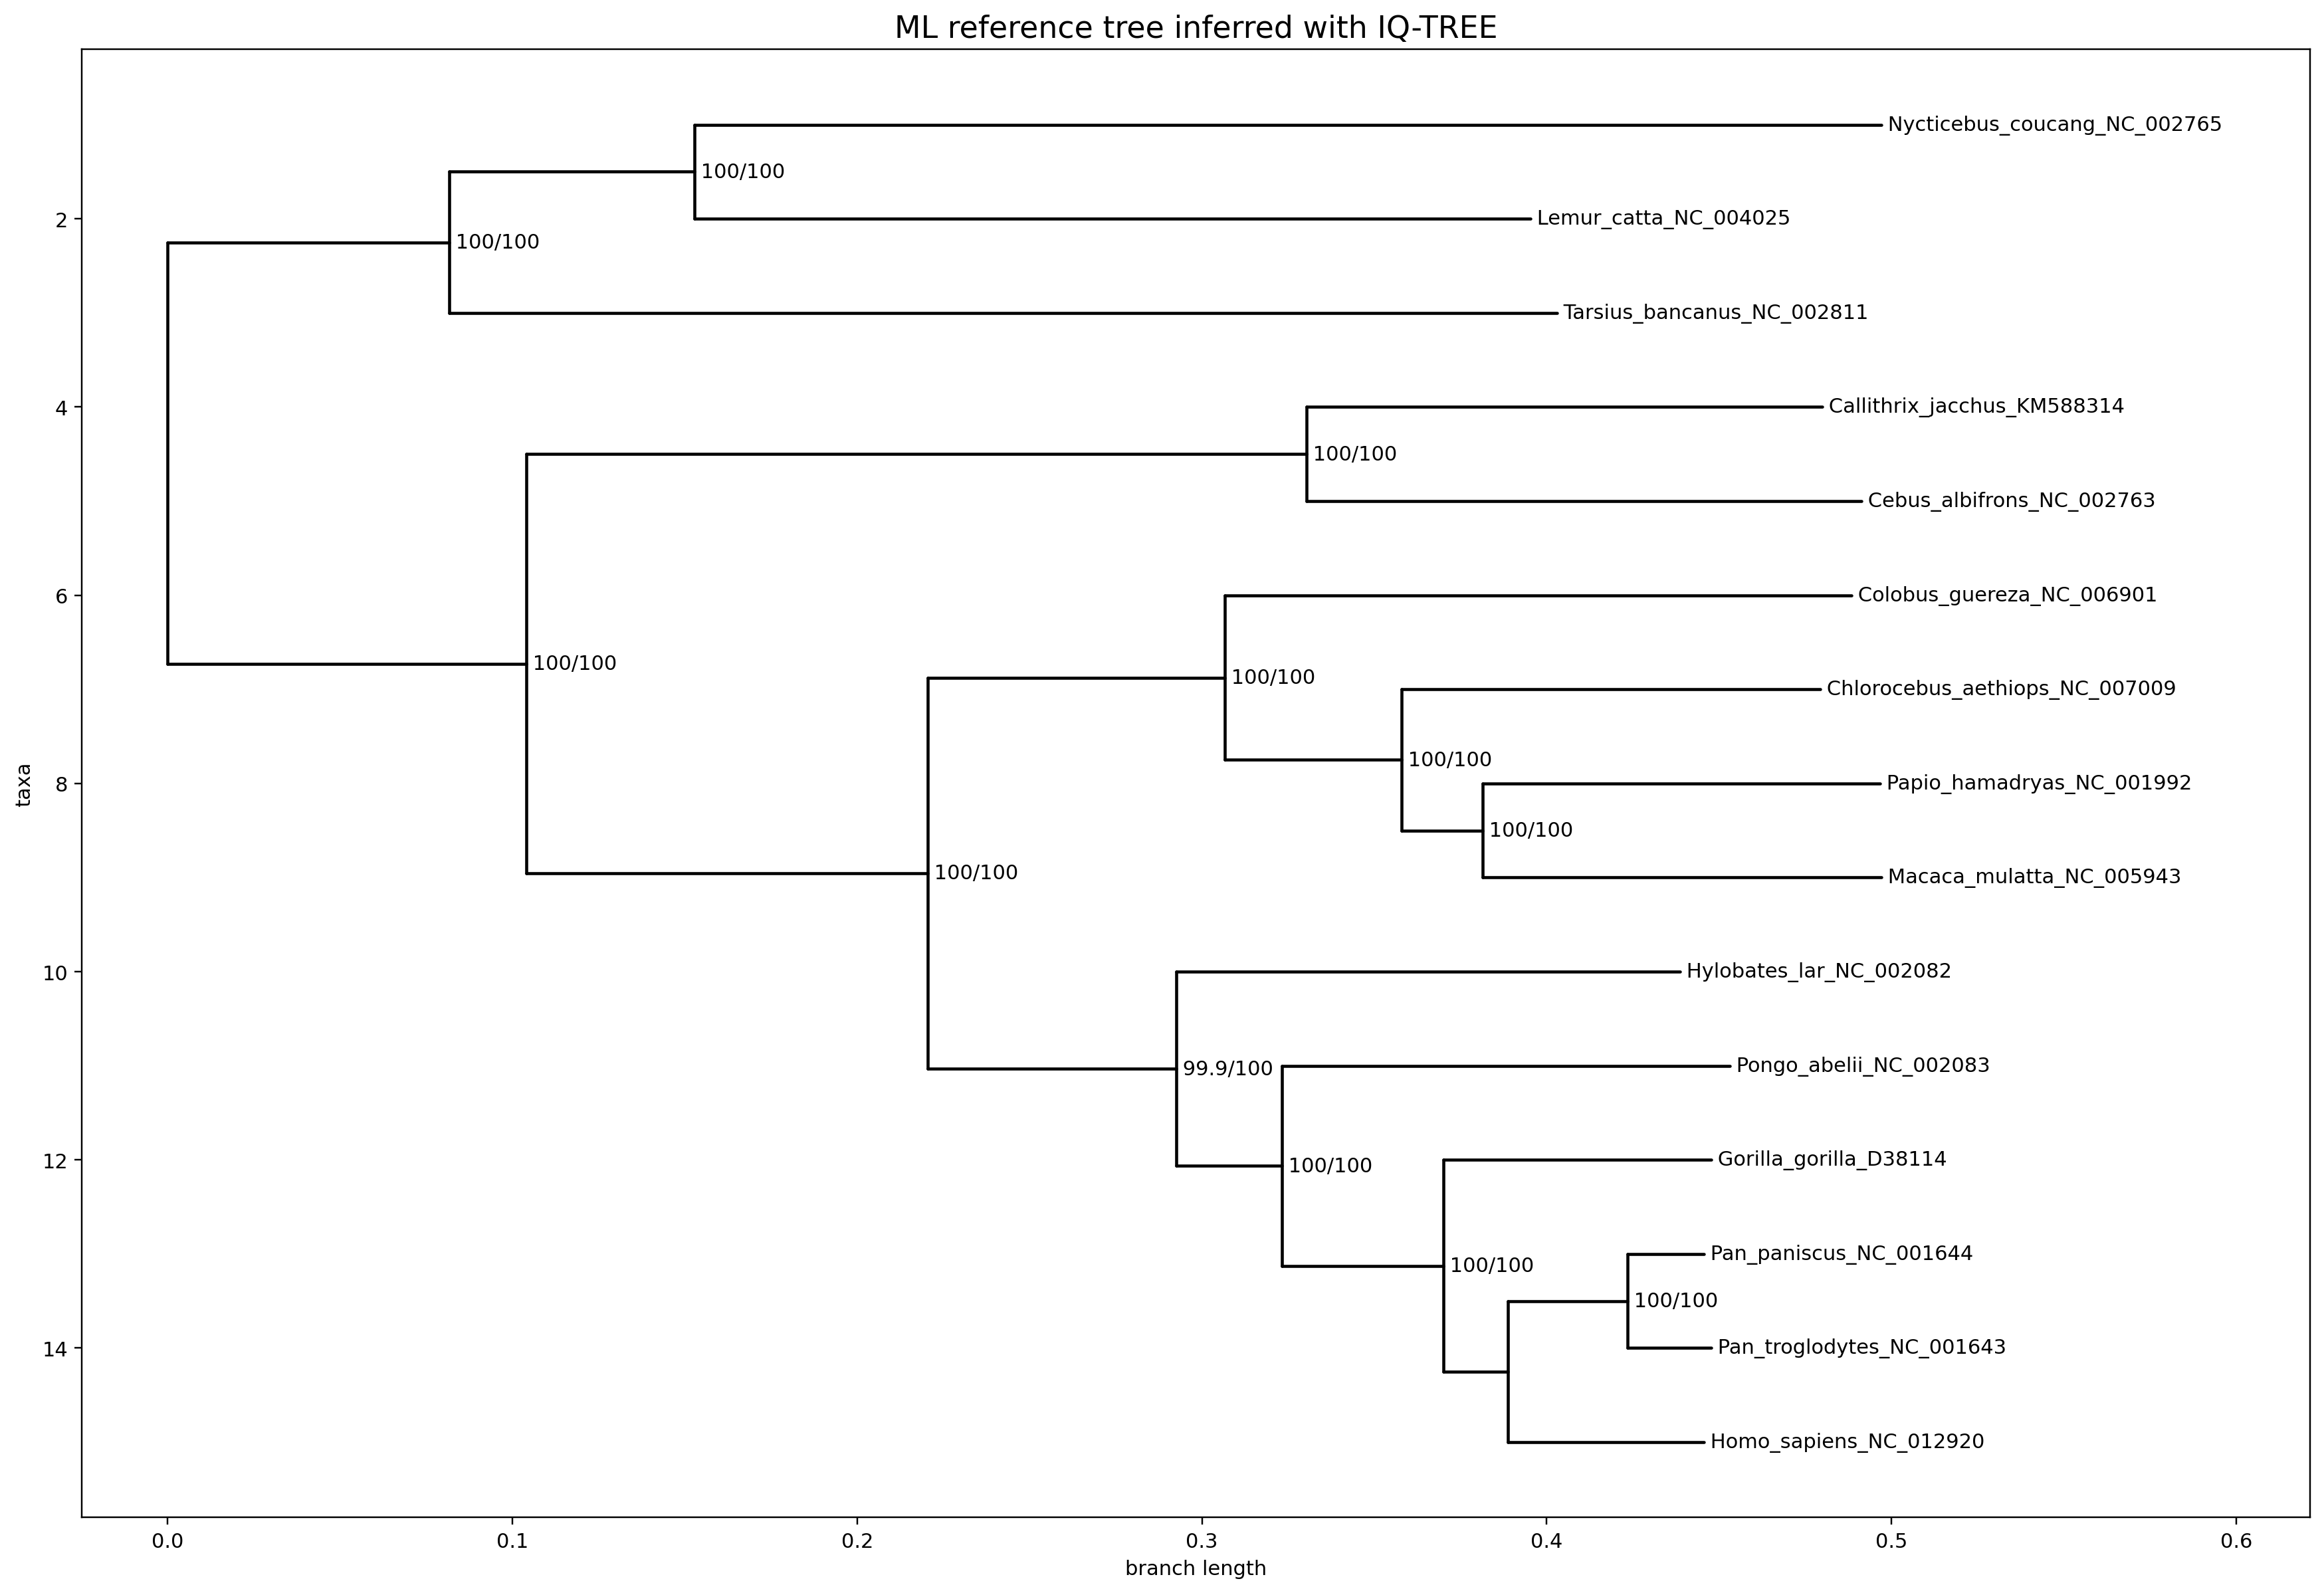

Saved: mtDNA15_heterogeneous_primate_ML_tree/mtDNA15_IQTREE_ML_tree_large_labels.png


In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
from Bio import Phylo

tree_path = "mtDNA15_heterogeneous_primate_ML_tree/mtDNA15_heterogeneous_primate_IQTREE_ML.treefile"
out_png = "mtDNA15_heterogeneous_primate_ML_tree/mtDNA15_IQTREE_ML_tree_large_labels.png"

tree = Phylo.read(tree_path, "newick")
tree.root_at_midpoint()

fig = plt.figure(figsize=(16, 11), dpi=220)
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=True,
    label_func=lambda clade: clade.name if clade.name else None
)

for text in ax.texts:
    text.set_fontsize(10)

ax.set_title("ML reference tree inferred with IQ-TREE", fontsize=15)
plt.tight_layout()
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved:", out_png)